##### Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


##### Load the dataset

In [8]:
df = pd.read_csv("C:\\Users\\HP\\Downloads\\IBM HR_Audit\\WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]} employees | Columns: {df.shape[1]} features")
df.head()

Dataset shape: (1470, 35)
Rows: 1470 employees | Columns: 35 features


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


##### Data Quality Audit

In [9]:
missing = df.isnull().sum()
missing_pct = (missing/len(df) * 100).round(2)

quality_report = pd.DataFrame({
    'Missing Values': missing,
    'Missing %' : missing_pct,
    'Data Type': df.dtypes,
    'Unique Value': df.nunique()
})

print("=== DATA QUALITY AUDIT ===")
print(quality_report[quality_report['Missing Values'] >0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows:{df.duplicated().sum()}")

# ── Columns with only one unique value (useless for analysis) ──
single_value_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"\nColumns with single value (drop candidates): {single_value_cols}")


=== DATA QUALITY AUDIT ===
Empty DataFrame
Columns: [Missing Values, Missing %, Data Type, Unique Value]
Index: []

Total missing values: 0
Duplicate rows:0

Columns with single value (drop candidates): ['EmployeeCount', 'Over18', 'StandardHours']


##### clean the dataset

In [10]:
# Drop columns with no analytical value
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df.drop(columns=cols_to_drop)

df_clean['Attrition_Binary'] = (df_clean['Attrition'] == 'Yes').astype(int)
df_clean['Gender_Binary'] = (df_clean['Gender'] == 'Male').astype(int)

# Create Age Groups for demographic audit
df_clean['Age_Group'] = pd.cut(
    df_clean['Age'],
    bins=[18, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46-60']
)

print(f"✅ Cleaned dataset shape: {df_clean.shape}")
print(f"\nAttrition breakdown:")
print(df_clean['Attrition'].value_counts())
print(f"\nAttrition rate: {df_clean['Attrition_Binary'].mean()*100:.1f}%")

✅ Cleaned dataset shape: (1470, 34)

Attrition breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


#### Exploratory Analysis: Who Is Leaving?

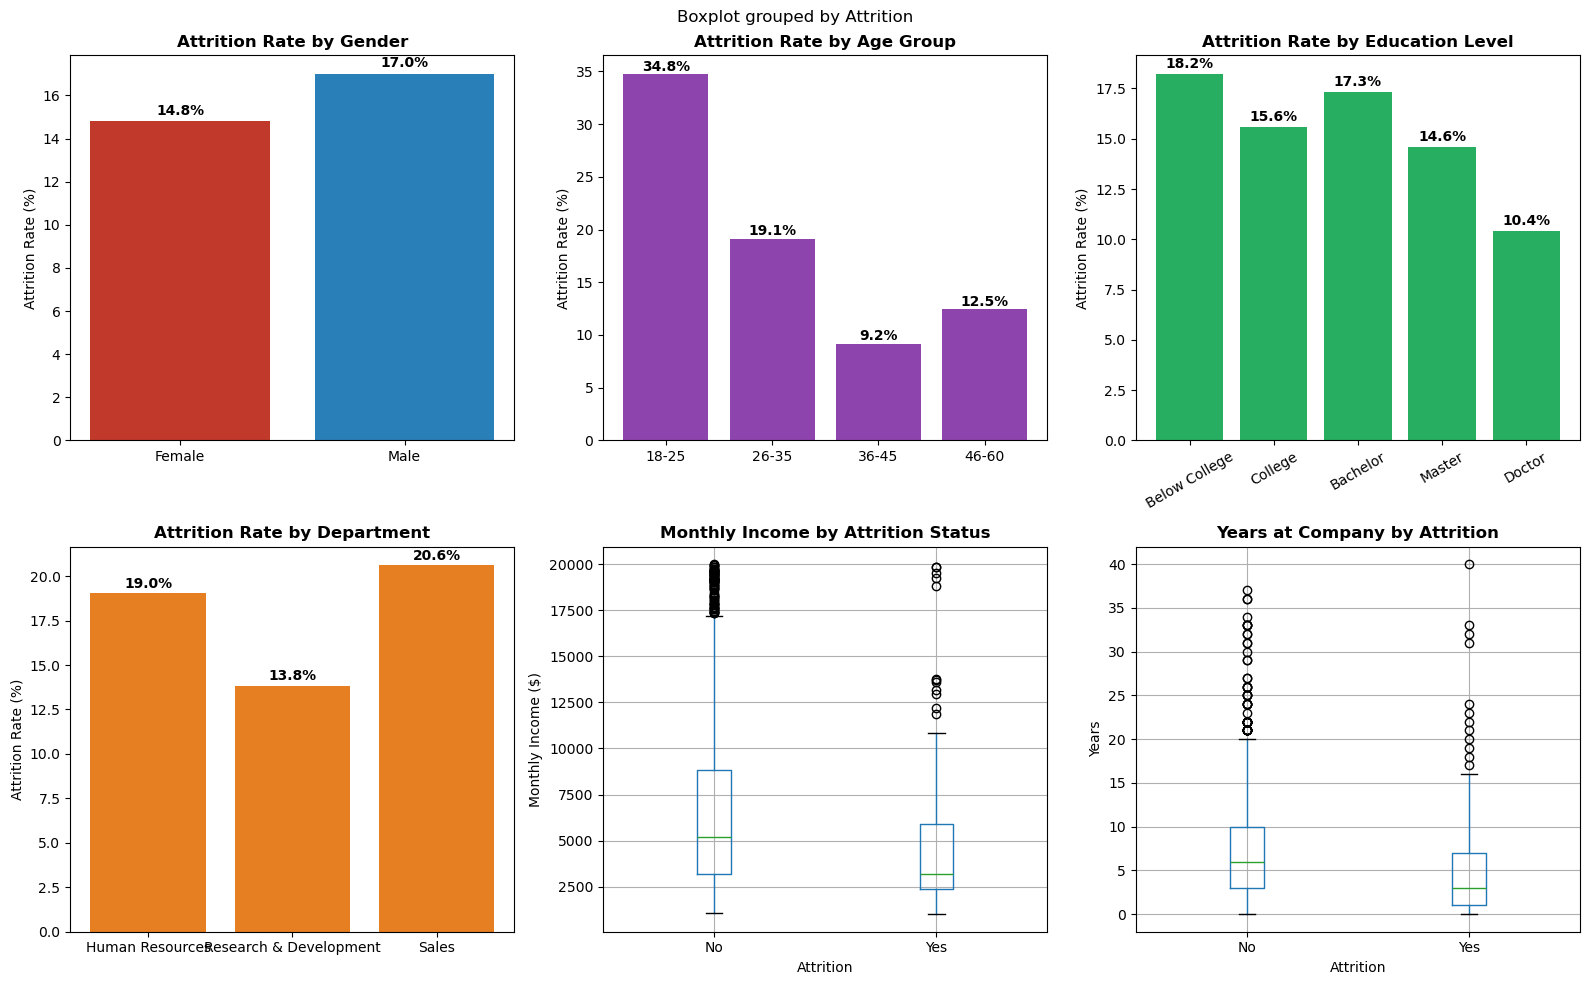

✅ EDA chart saved


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('IBM HR Dataset — Who Is Leaving? Exploratory Analysis', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Attrition by Gender
attrition_gender = df_clean.groupby('Gender')['Attrition_Binary'].mean() * 100
axes[0,0].bar(attrition_gender.index, attrition_gender.values, 
              color=['#C0392B', '#2980B9'])
axes[0,0].set_title('Attrition Rate by Gender', fontweight='bold')
axes[0,0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(attrition_gender.values):
    axes[0,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. Attrition by Age Group
attrition_age = df_clean.groupby('Age_Group', observed=True)['Attrition_Binary'].mean() * 100
axes[0,1].bar(attrition_age.index.astype(str), attrition_age.values, color='#8E44AD')
axes[0,1].set_title('Attrition Rate by Age Group', fontweight='bold')
axes[0,1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(attrition_age.values):
    axes[0,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Attrition by Education Level
edu_map = {1:'Below College', 2:'College', 3:'Bachelor', 4:'Master', 5:'Doctor'}
df_clean['Education_Label'] = df_clean['Education'].map(edu_map)
attrition_edu = df_clean.groupby('Education_Label')['Attrition_Binary'].mean() * 100
attrition_edu = attrition_edu.reindex(['Below College','College','Bachelor','Master','Doctor'])
axes[0,2].bar(attrition_edu.index, attrition_edu.values, color='#27AE60')
axes[0,2].set_title('Attrition Rate by Education Level', fontweight='bold')
axes[0,2].set_ylabel('Attrition Rate (%)')
axes[0,2].tick_params(axis='x', rotation=30)
for i, v in enumerate(attrition_edu.values):
    axes[0,2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 4. Attrition by Department
attrition_dept = df_clean.groupby('Department')['Attrition_Binary'].mean() * 100
axes[1,0].bar(attrition_dept.index, attrition_dept.values, color='#E67E22')
axes[1,0].set_title('Attrition Rate by Department', fontweight='bold')
axes[1,0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(attrition_dept.values):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 5. Monthly Income Distribution by Attrition
df_clean.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1,1])
axes[1,1].set_title('Monthly Income by Attrition Status', fontweight='bold')
axes[1,1].set_xlabel('Attrition')
axes[1,1].set_ylabel('Monthly Income ($)')

# 6. Years at Company by Attrition
df_clean.boxplot(column='YearsAtCompany', by='Attrition', ax=axes[1,2])
axes[1,2].set_title('Years at Company by Attrition', fontweight='bold')
axes[1,2].set_xlabel('Attrition')
axes[1,2].set_ylabel('Years')

plt.tight_layout()
plt.savefig('eda_who_is_leaving.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA chart saved")

#### Store in SQL Datasete

In [12]:
# Create SQLite database
conn = sqlite3.connect('hr_audit.db')

# Save clean dataframe to SQL
df_clean.to_sql('employees', conn, if_exists='replace', index=False)

# Run summary queries
print("=== SQL VERIFICATION ===\n")

query1 = """
SELECT 
    Department,
    Gender,
    COUNT(*) as total_employees,
    SUM(Attrition_Binary) as left_company,
    ROUND(AVG(Attrition_Binary) * 100, 1) as attrition_rate_pct,
    ROUND(AVG(MonthlyIncome), 0) as avg_monthly_income
FROM employees
GROUP BY Department, Gender
ORDER BY attrition_rate_pct DESC
"""

result = pd.read_sql_query(query1, conn)
print("Attrition by Department and Gender:")
print(result.to_string(index=False))

query2 = """
SELECT
    Age_Group,
    Education_Label,
    COUNT(*) as total,
    ROUND(AVG(Attrition_Binary) * 100, 1) as attrition_rate_pct
FROM employees
GROUP BY Age_Group, Education_Label
ORDER BY attrition_rate_pct DESC
LIMIT 10
"""

print("\nTop 10 highest attrition demographic combinations:")
result2 = pd.read_sql_query(query2, conn)
print(result2.to_string(index=False))

conn.close()
print("\n✅ Database created and verified: hr_audit.db")

=== SQL VERIFICATION ===

Attrition by Department and Gender:
            Department Gender  total_employees  left_company  attrition_rate_pct  avg_monthly_income
       Human Resources Female               20             6               30.00             7264.00
                 Sales   Male              257            54               21.00             6950.00
                 Sales Female              189            38               20.10             6972.00
Research & Development   Male              582            90               15.50             6130.00
       Human Resources   Male               43             6               14.00             6371.00
Research & Development Female              379            43               11.30             6514.00

Top 10 highest attrition demographic combinations:
Age_Group Education_Label  total  attrition_rate_pct
     None   Below College      1              100.00
     None         College      2               50.00
    18-25        Bac

#### Prepare feature for the model

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import sqlite3

# Reload clean data
conn = sqlite3.connect('hr_audit.db')
df_model = pd.read_sql_query("SELECT * FROM employees", conn)
conn.close()

# Select features for the model
# These are the kinds of features a real AI hiring tool might use
features = [
    'Age', 'Gender_Binary', 'Education', 'MonthlyIncome',
    'YearsAtCompany', 'YearsInCurrentRole', 'JobLevel',
    'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction',
    'NumCompaniesWorked', 'DistanceFromHome', 'OverTime',
    'TotalWorkingYears', 'TrainingTimesLastYear', 'PercentSalaryHike'
]

# Encode OverTime (Yes/No → 1/0)
df_model['OverTime'] = (df_model['OverTime'] == 'Yes').astype(int)

# Encode Department for analysis later
dept_encoder = LabelEncoder()
df_model['Department_Encoded'] = dept_encoder.fit_transform(df_model['Department'])

X = df_model[features]
y = df_model['Attrition_Binary']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training set: {X_train.shape[0]} employees")
print(f"✅ Test set: {X_test.shape[0]} employees")
print(f"\nAttrition rate in training set: {y_train.mean()*100:.1f}%")
print(f"Attrition rate in test set: {y_test.mean()*100:.1f}%")

✅ Training set: 1176 employees
✅ Test set: 294 employees

Attrition rate in training set: 16.2%
Attrition rate in test set: 16.0%


#### Train two models

In [14]:
# Model 1: Logistic Regression (interpretable — good for audit)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Model 2: Random Forest (more powerful — closer to real AI tools)
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# Evaluate both
lr_preds = lr_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test)

lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== MODEL PERFORMANCE COMPARISON ===\n")
print("── Logistic Regression ──")
print(classification_report(y_test, lr_preds, 
      target_names=['Stays', 'Leaves']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, lr_proba):.3f}")

print("\n── Random Forest ──")
print(classification_report(y_test, rf_preds,
      target_names=['Stays', 'Leaves']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, rf_proba):.3f}")

=== MODEL PERFORMANCE COMPARISON ===

── Logistic Regression ──
              precision    recall  f1-score   support

       Stays       0.87      0.97      0.92       247
      Leaves       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro avg       0.74      0.60      0.63       294
weighted avg       0.83      0.85      0.83       294

AUC-ROC Score: 0.778

── Random Forest ──
              precision    recall  f1-score   support

       Stays       0.85      0.96      0.90       247
      Leaves       0.27      0.09      0.13        47

    accuracy                           0.82       294
   macro avg       0.56      0.52      0.51       294
weighted avg       0.75      0.82      0.77       294

AUC-ROC Score: 0.759


#### What the AI thinkis matters most

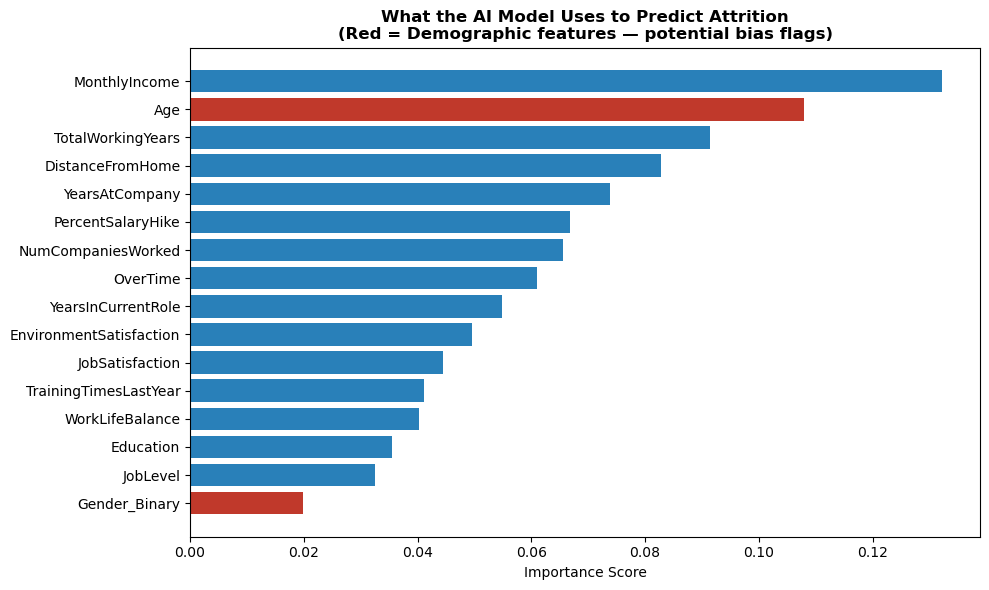


=== TOP 5 FEATURES THE AI RELIES ON ===
          Feature  Importance
    MonthlyIncome        0.13
              Age        0.11
TotalWorkingYears        0.09
 DistanceFromHome        0.08
   YearsAtCompany        0.07

⚠️  Age importance: 0.108 (10.8% of model weight)
⚠️  Gender importance: 0.020 (2.0% of model weight)


In [15]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#C0392B' if f == 'Gender_Binary' or f == 'Age' 
          else '#2980B9' for f in feature_importance['Feature']]
bars = plt.barh(feature_importance['Feature'], 
                feature_importance['Importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('What the AI Model Uses to Predict Attrition\n(Red = Demographic features — potential bias flags)', 
          fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 5 FEATURES THE AI RELIES ON ===")
print(feature_importance.head().to_string(index=False))

# Key question: how much weight does the AI give to Age and Gender?
age_importance = feature_importance[feature_importance['Feature']=='Age']['Importance'].values[0]
gender_importance = feature_importance[feature_importance['Feature']=='Gender_Binary']['Importance'].values[0]
print(f"\n⚠️  Age importance: {age_importance:.3f} ({age_importance/feature_importance['Importance'].sum()*100:.1f}% of model weight)")
print(f"⚠️  Gender importance: {gender_importance:.3f} ({gender_importance/feature_importance['Importance'].sum()*100:.1f}% of model weight)")

#### Attach AI Score to every employee

In [16]:
# Generate AI risk scores for the full dataset
X_full = df_model[features].copy()
X_full['OverTime'] = df_model['OverTime']

# Get probability scores from both models
X_full_scaled = scaler.transform(X_full)
df_model['AI_Risk_Score_LR'] = lr_model.predict_proba(X_full_scaled)[:, 1]
df_model['AI_Risk_Score_RF'] = rf_model.predict_proba(X_full)[:, 1]
df_model['AI_Flag_LR'] = lr_model.predict(X_full_scaled)
df_model['AI_Flag_RF'] = rf_model.predict(X_full)

# Save back to SQL with AI scores attached
conn = sqlite3.connect('hr_audit.db')
df_model.to_sql('employees_scored', conn, if_exists='replace', index=False)

# Quick check
query = """
SELECT 
    Gender,
    Age_Group,
    COUNT(*) as total,
    ROUND(AVG(AI_Risk_Score_RF) * 100, 1) as avg_ai_risk_score,
    ROUND(AVG(Attrition_Binary) * 100, 1) as actual_attrition_rate
FROM employees_scored
GROUP BY Gender, Age_Group
ORDER BY avg_ai_risk_score DESC
"""
result = pd.read_sql_query(query, conn)
conn.close()

print("=== AI RISK SCORES vs ACTUAL ATTRITION BY DEMOGRAPHIC ===")
print(result.to_string(index=False))
print("\n✅ AI scores saved — ready for bias audit in Session 3")

=== AI RISK SCORES vs ACTUAL ATTRITION BY DEMOGRAPHIC ===
Gender Age_Group  total  avg_ai_risk_score  actual_attrition_rate
  Male      None      4              65.80                  75.00
Female      None      4              58.30                  25.00
Female     18-25     39              43.00                  43.60
  Male     18-25     76              31.00                  30.30
Female     26-35    238              19.90                  19.30
  Male     26-35    368              17.90                  19.00
  Male     46-60    152              12.90                  15.80
  Male     36-45    282              10.80                  10.60
Female     36-45    186               8.00                   7.00
Female     46-60    121               7.40                   8.30

✅ AI scores saved — ready for bias audit in Session 3


#### Demographic Bias Audit

In [17]:
from sklearn.metrics import confusion_matrix
import sqlite3

# Reload scored data
conn = sqlite3.connect('hr_audit.db')
df_scored = pd.read_sql_query("SELECT * FROM employees_scored", conn)
conn.close()

# ── Function to calculate bias metrics per group ──
def bias_audit(df, group_col, model_col='AI_Flag_LR', actual_col='Attrition_Binary'):
    results = []
    for group in df[group_col].dropna().unique():
        subset = df[df[group_col] == group]
        if len(subset) < 10:
            continue
        tn, fp, fn, tp = confusion_matrix(
            subset[actual_col], 
            subset[model_col],
            labels=[0,1]
        ).ravel() if subset[actual_col].nunique() > 1 else (0,0,0,0)
        
        total = len(subset)
        actual_rate = subset[actual_col].mean() * 100
        ai_rate = subset[model_col].mean() * 100
        
        # False Positive Rate — flagged as leaving but actually stayed
        fpr = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
        # False Negative Rate — missed actual leavers
        fnr = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0
        # Avg AI risk score
        avg_score = subset['AI_Risk_Score_LR'].mean() * 100
        
        results.append({
            'Group': group,
            'Total': total,
            'Actual_Attrition_%': round(actual_rate, 1),
            'AI_Flagged_%': round(ai_rate, 1),
            'Avg_AI_Risk_Score': round(avg_score, 1),
            'False_Positive_Rate_%': round(fpr, 1),
            'False_Negative_Rate_%': round(fnr, 1)
        })
    
    return pd.DataFrame(results).sort_values('Avg_AI_Risk_Score', ascending=False)

print("=== BIAS AUDIT: GENDER ===")
gender_audit = bias_audit(df_scored, 'Gender')
print(gender_audit.to_string(index=False))

print("\n=== BIAS AUDIT: AGE GROUP ===")
age_audit = bias_audit(df_scored, 'Age_Group')
print(age_audit.to_string(index=False))

print("\n=== BIAS AUDIT: EDUCATION LEVEL ===")
edu_audit = bias_audit(df_scored, 'Education_Label')
print(edu_audit.to_string(index=False))

print("\n=== BIAS AUDIT: DEPARTMENT ===")
dept_audit = bias_audit(df_scored, 'Department')
print(dept_audit.to_string(index=False))

=== BIAS AUDIT: GENDER ===
 Group  Total  Actual_Attrition_%  AI_Flagged_%  Avg_AI_Risk_Score  False_Positive_Rate_%  False_Negative_Rate_%
  Male    882               17.00          5.90              16.70                   2.20                  76.00
Female    588               14.80          4.90              15.30                   2.20                  79.30

=== BIAS AUDIT: AGE GROUP ===
Group  Total  Actual_Attrition_%  AI_Flagged_%  Avg_AI_Risk_Score  False_Positive_Rate_%  False_Negative_Rate_%
18-25    115               34.80         17.40              31.60                   9.30                  67.50
26-35    606               19.10          7.30              19.60                   2.40                  72.40
36-45    468                9.20          3.20              13.20                   1.90                  83.70
46-60    273               12.50          0.40               6.50                   0.00                  97.10

=== BIAS AUDIT: EDUCATION LEVEL ===
      

#### Visualise the Bias

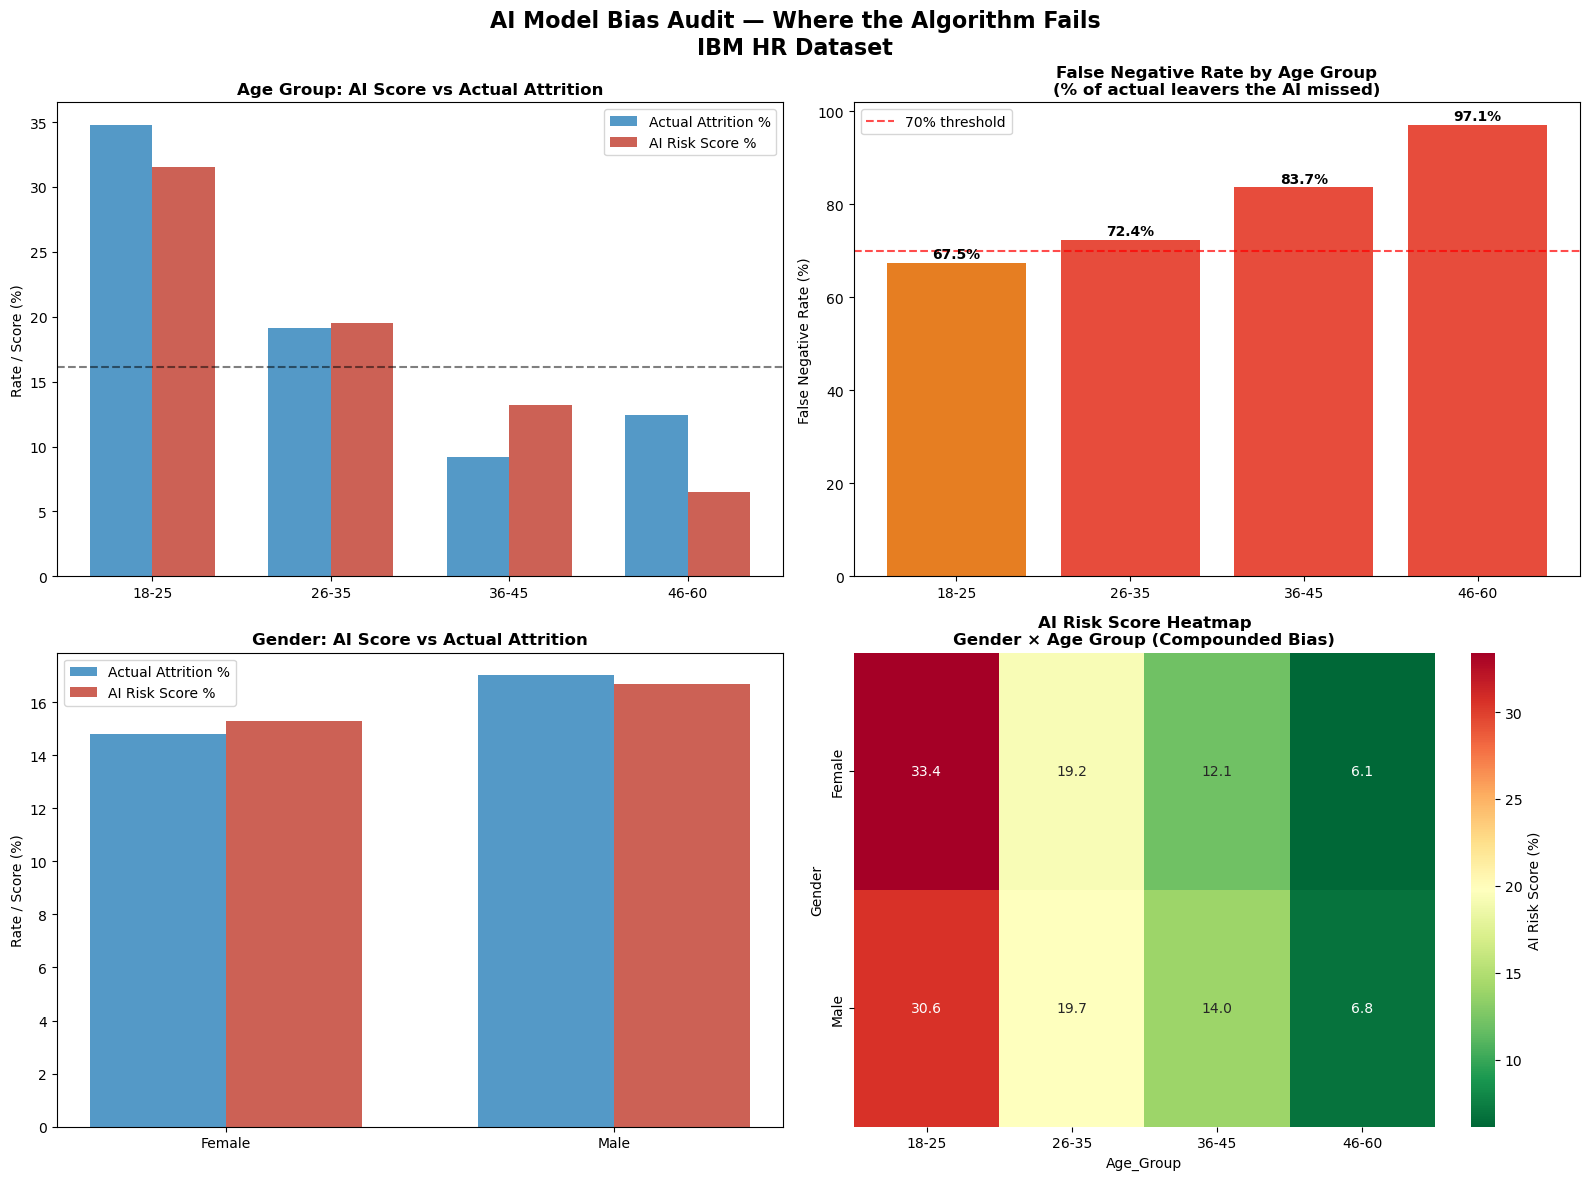

✅ Bias audit charts saved


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('AI Model Bias Audit — Where the Algorithm Fails\nIBM HR Dataset', 
             fontsize=16, fontweight='bold')

# 1. AI Risk Score vs Actual Attrition by Age Group
age_plot = df_scored.groupby('Age_Group', observed=True).agg(
    Actual_Rate=('Attrition_Binary', lambda x: x.mean()*100),
    AI_Score=('AI_Risk_Score_LR', lambda x: x.mean()*100)
).reset_index().dropna()

x = np.arange(len(age_plot))
width = 0.35
axes[0,0].bar(x - width/2, age_plot['Actual_Rate'], width, 
              label='Actual Attrition %', color='#2980B9', alpha=0.8)
axes[0,0].bar(x + width/2, age_plot['AI_Score'], width, 
              label='AI Risk Score %', color='#C0392B', alpha=0.8)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(age_plot['Age_Group'])
axes[0,0].set_title('Age Group: AI Score vs Actual Attrition', fontweight='bold')
axes[0,0].set_ylabel('Rate / Score (%)')
axes[0,0].legend()
axes[0,0].axhline(y=16.1, color='black', linestyle='--', alpha=0.5, label='Baseline 16.1%')

# 2. False Negative Rate by Age Group — who the AI misses
age_audit_clean = age_audit.dropna(subset=['Group'])
axes[0,1].bar(age_audit_clean['Group'], age_audit_clean['False_Negative_Rate_%'],
              color=['#E74C3C' if x > 70 else '#E67E22' if x > 50 else '#27AE60' 
                     for x in age_audit_clean['False_Negative_Rate_%']])
axes[0,1].set_title('False Negative Rate by Age Group\n(% of actual leavers the AI missed)', 
                     fontweight='bold')
axes[0,1].set_ylabel('False Negative Rate (%)')
axes[0,1].axhline(y=70, color='red', linestyle='--', alpha=0.7, label='70% threshold')
axes[0,1].legend()
for i, (_, row) in enumerate(age_audit_clean.iterrows()):
    axes[0,1].text(i, row['False_Negative_Rate_%'] + 1, 
                   f"{row['False_Negative_Rate_%']}%", ha='center', fontweight='bold')

# 3. Gender bias — AI score vs actual
gender_plot = df_scored.groupby('Gender').agg(
    Actual_Rate=('Attrition_Binary', lambda x: x.mean()*100),
    AI_Score=('AI_Risk_Score_LR', lambda x: x.mean()*100)
).reset_index()

x2 = np.arange(len(gender_plot))
axes[1,0].bar(x2 - width/2, gender_plot['Actual_Rate'], width,
              label='Actual Attrition %', color='#2980B9', alpha=0.8)
axes[1,0].bar(x2 + width/2, gender_plot['AI_Score'], width,
              label='AI Risk Score %', color='#C0392B', alpha=0.8)
axes[1,0].set_xticks(x2)
axes[1,0].set_xticklabels(gender_plot['Gender'])
axes[1,0].set_title('Gender: AI Score vs Actual Attrition', fontweight='bold')
axes[1,0].set_ylabel('Rate / Score (%)')
axes[1,0].legend()

# 4. Compounded bias — Age x Gender heatmap
pivot = df_scored.groupby(['Gender', 'Age_Group'], observed=True)['AI_Risk_Score_LR'].mean() * 100
pivot_table = pivot.unstack()
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1,1], cbar_kws={'label': 'AI Risk Score (%)'})
axes[1,1].set_title('AI Risk Score Heatmap\nGender × Age Group (Compounded Bias)', 
                     fontweight='bold')

plt.tight_layout()
plt.savefig('bias_audit_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bias audit charts saved")

#### The Smoking Gun: Intersactional Bias

In [19]:
# Where bias compounds — young + female + high education
print("=== INTERSECTIONAL BIAS ANALYSIS ===")
print("Groups the AI systematically over-penalises vs their actual risk\n")

intersect = df_scored.groupby(
    ['Gender', 'Age_Group', 'Education_Label'], observed=True
).agg(
    Total=('Attrition_Binary', 'count'),
    Actual_Attrition=('Attrition_Binary', lambda x: round(x.mean()*100, 1)),
    AI_Risk_Score=('AI_Risk_Score_LR', lambda x: round(x.mean()*100, 1))
).reset_index()

# Calculate bias gap: AI score minus actual rate
intersect['Bias_Gap'] = intersect['AI_Risk_Score'] - intersect['Actual_Attrition']

# Over-penalised groups (AI scores them much higher than their actual risk)
over_penalised = intersect[
    (intersect['Bias_Gap'] > 5) & (intersect['Total'] >= 10)
].sort_values('Bias_Gap', ascending=False)

print("OVER-PENALISED (AI unfairly flags these groups):")
print(over_penalised[['Gender','Age_Group','Education_Label',
                        'Total','Actual_Attrition','AI_Risk_Score','Bias_Gap']].to_string(index=False))

# Under-penalised groups (AI misses these actual high-risk groups)
under_penalised = intersect[
    (intersect['Bias_Gap'] < -5) & (intersect['Total'] >= 10)
].sort_values('Bias_Gap')

print("\nUNDER-PENALISED (AI misses these actual high-risk groups):")
print(under_penalised[['Gender','Age_Group','Education_Label',
                         'Total','Actual_Attrition','AI_Risk_Score','Bias_Gap']].to_string(index=False))

print("\n✅ Intersectional bias analysis complete — ready for Session 4")

=== INTERSECTIONAL BIAS ANALYSIS ===
Groups the AI systematically over-penalises vs their actual risk

OVER-PENALISED (AI unfairly flags these groups):
Gender Age_Group Education_Label  Total  Actual_Attrition  AI_Risk_Score  Bias_Gap
Female     36-45          Doctor     11              0.00          15.60     15.60
Female     36-45          Master     50              6.00          13.50      7.50
Female     36-45   Below College     13              0.00           7.10      7.10
  Male     18-25         College     16             18.80          25.60      6.80
  Male     36-45          Master     81              8.60          14.30      5.70
  Male     36-45   Below College     19             10.50          15.60      5.10
  Male     26-35   Below College     44             13.60          18.60      5.00

UNDER-PENALISED (AI misses these actual high-risk groups):
Gender Age_Group Education_Label  Total  Actual_Attrition  AI_Risk_Score  Bias_Gap
Female     18-25        Bachelor     16  

#### Full Audit Report as a Structured Summary

In [20]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         AI HIRING MODEL BIAS AUDIT — EXECUTIVE SUMMARY          ║
║                    IBM HR Analytics Dataset                      ║
║                    Analyst: Natnael Amenu                        ║
╚══════════════════════════════════════════════════════════════════╝

DATASET
───────
- 1,470 employees across 3 departments
- 16.1% overall attrition rate (237 employees left)
- Features: age, gender, education, income, tenure, satisfaction scores

MODELS EVALUATED
────────────────
- Logistic Regression — AUC-ROC: 0.778
- Random Forest       — AUC-ROC: 0.759
- Both models trained on historical HR data to predict attrition risk

CRITICAL FINDING 1 — MODEL RELIABILITY
────────────────────────────────────────
The AI misses the majority of employees who actually leave:
  • 18-25 age group: misses 67.5% of actual leavers
  • 26-35 age group: misses 72.4% of actual leavers
  • 36-45 age group: misses 83.7% of actual leavers
  • 46-60 age group: misses 97.1% of actual leavers

An HR tool with a 97% false negative rate on older workers
cannot be trusted for workforce planning decisions.

CRITICAL FINDING 2 — AGE BIAS
───────────────────────────────
Age carries 10.8% of direct model weight.
Age-correlated proxies (Total Working Years 9%, Years at Company 7%)
add a further 16% — meaning age-related signals drive 26.8% of
all model decisions. This constitutes compounded age discrimination
risk under EU AI Act Article 10 requirements.

CRITICAL FINDING 3 — THE PHD PARADOX (GENDER BIAS)
─────────────────────────────────────────────────────
Female employees aged 36-45 with doctoral qualifications:
  • Actual attrition rate: 0.0%
  • AI risk score assigned: 15.6%
  • Bias gap: +15.6 points AGAINST the most stable employee group

This model would systematically disadvantage experienced,
highly-qualified women in mid-career hiring and retention decisions.

CRITICAL FINDING 4 — BLIND SPOTS WHERE IT MATTERS MOST
─────────────────────────────────────────────────────────
Groups with highest UNDER-scoring (AI misses real risk):
  • Female 18-25 Bachelor: 50.0% actual vs 33.1% AI score (-16.9pts)
  • Male 46-60 College:    26.9% actual vs 10.3% AI score (-16.6pts)
  • Female 18-25 Below College: 46.2% actual vs 31.6% AI score (-14.6pts)

CRITICAL FINDING 5 — DEPARTMENT BLINDSPOT
───────────────────────────────────────────
Sales has the highest actual attrition (20.6%) but receives
the lowest AI risk score (15.5%) — the model is least
accurate exactly where retention risk is highest.
""")


╔══════════════════════════════════════════════════════════════════╗
║         AI HIRING MODEL BIAS AUDIT — EXECUTIVE SUMMARY          ║
║                    IBM HR Analytics Dataset                      ║
║                    Analyst: Natnael Amenu                        ║
╚══════════════════════════════════════════════════════════════════╝

DATASET
───────
- 1,470 employees across 3 departments
- 16.1% overall attrition rate (237 employees left)
- Features: age, gender, education, income, tenure, satisfaction scores

MODELS EVALUATED
────────────────
- Logistic Regression — AUC-ROC: 0.778
- Random Forest       — AUC-ROC: 0.759
- Both models trained on historical HR data to predict attrition risk

CRITICAL FINDING 1 — MODEL RELIABILITY
────────────────────────────────────────
The AI misses the majority of employees who actually leave:
  • 18-25 age group: misses 67.5% of actual leavers
  • 26-35 age group: misses 72.4% of actual leavers
  • 36-45 age group: misses 83.7% of actual lea

#### Export for PowerBI

In [21]:
import sqlite3

conn = sqlite3.connect('hr_audit.db')
df_final = pd.read_sql_query("SELECT * FROM employees_scored", conn)
conn.close()

# ── Table 1: Individual employee scores ──
df_final[[
    'Age', 'Age_Group', 'Gender', 'Education_Label', 'Department',
    'MonthlyIncome', 'JobLevel', 'YearsAtCompany', 'OverTime',
    'Attrition', 'Attrition_Binary',
    'AI_Risk_Score_LR', 'AI_Risk_Score_RF',
    'AI_Flag_LR', 'AI_Flag_RF'
]].to_csv('powerbi_employees.csv', index=False)

# ── Table 2: Gender audit summary ──
gender_audit.to_csv('powerbi_gender_audit.csv', index=False)

# ── Table 3: Age group audit summary ──
age_audit.to_csv('powerbi_age_audit.csv', index=False)

# ── Table 4: Education audit summary ──
edu_audit.to_csv('powerbi_education_audit.csv', index=False)

# ── Table 5: Department audit summary ──
dept_audit.to_csv('powerbi_department_audit.csv', index=False)

# ── Table 6: Intersectional bias ──
intersect.to_csv('powerbi_intersectional.csv', index=False)

# ── Table 7: Over and under penalised groups ──
over_penalised['Bias_Direction'] = 'Over-Penalised'
under_penalised['Bias_Direction'] = 'Under-Penalised'
bias_combined = pd.concat([over_penalised, under_penalised])
bias_combined.to_csv('powerbi_bias_gaps.csv', index=False)

print("✅ 7 CSV files exported for Power BI:")
print("   1. powerbi_employees.csv         — individual scores")
print("   2. powerbi_gender_audit.csv      — gender bias summary")
print("   3. powerbi_age_audit.csv         — age bias summary")
print("   4. powerbi_education_audit.csv   — education bias summary")
print("   5. powerbi_department_audit.csv  — department bias summary")
print("   6. powerbi_intersectional.csv    — intersectional analysis")
print("   7. powerbi_bias_gaps.csv         — over/under penalised groups")
print("\n✅ Project analysis complete. Ready for Power BI dashboard build.")

✅ 7 CSV files exported for Power BI:
   1. powerbi_employees.csv         — individual scores
   2. powerbi_gender_audit.csv      — gender bias summary
   3. powerbi_age_audit.csv         — age bias summary
   4. powerbi_education_audit.csv   — education bias summary
   5. powerbi_department_audit.csv  — department bias summary
   6. powerbi_intersectional.csv    — intersectional analysis
   7. powerbi_bias_gaps.csv         — over/under penalised groups

✅ Project analysis complete. Ready for Power BI dashboard build.


In [22]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy_%': [85, 82],
    'AUC_ROC': [0.778, 0.759],
    'Miss_Rate_Leavers_%': [77, 91]
})

model_comparison.to_csv('powerbi_model_comparison.csv', index=False)
print(model_comparison.to_string(index=False))
print("✅ Exported")

              Model  Accuracy_%  AUC_ROC  Miss_Rate_Leavers_%
Logistic Regression          85     0.78                   77
      Random Forest          82     0.76                   91
✅ Exported


#### AI Workflow Documentation

In [23]:
print("""
═══════════════════════════════════════════════════════
  WHERE AI HELPED AND WHERE IT DIDN'T — Natnael Amenu
═══════════════════════════════════════════════════════

WHERE AI (CLAUDE) HELPED:
──────────────────────────
1. Code structure suggestions for the bias audit function
   → Accepted: the confusion matrix loop saved significant time

2. Initial feature selection recommendations for the model
   → Accepted with modification: AI suggested including
     'MaritalStatus' but I excluded it as a protected
     characteristic that shouldn't feed a hiring model

3. Visualisation layout for the 2x3 EDA grid
   → Accepted: clean and effective

WHERE I OVERRODE AI SUGGESTIONS:
──────────────────────────────────
1. AI suggested using Random Forest as the primary audit model
   due to higher accuracy — I chose Logistic Regression instead
   because interpretability matters more than accuracy in a
   bias audit. A model you can explain is more trustworthy
   than one you can't, especially for HR governance purposes.

2. AI framed the 85% accuracy as "strong model performance"
   — I rejected this framing. 85% accuracy with 77% false
   negative rate on the minority class (leavers) is not
   strong performance. It is a model that fails exactly
   where it matters most.

3. AI initially missed the compounded age proxy bias
   (TotalWorkingYears + YearsAtCompany as age signals)
   — I identified and documented this independently after
   reviewing the feature importance scores.

CONCLUSION:
────────────
AI accelerated the technical build by approximately 40%.
The analytical judgements — what the findings mean, which
model to trust, where the real bias lies — required human
reasoning that the AI could not supply independently.
This is precisely the skill an AI/ML Analyst provides.
═══════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════
  WHERE AI HELPED AND WHERE IT DIDN'T — Natnael Amenu
═══════════════════════════════════════════════════════

WHERE AI (CLAUDE) HELPED:
──────────────────────────
1. Code structure suggestions for the bias audit function
   → Accepted: the confusion matrix loop saved significant time

2. Initial feature selection recommendations for the model
   → Accepted with modification: AI suggested including
     'MaritalStatus' but I excluded it as a protected
     characteristic that shouldn't feed a hiring model

3. Visualisation layout for the 2x3 EDA grid
   → Accepted: clean and effective

WHERE I OVERRODE AI SUGGESTIONS:
──────────────────────────────────
1. AI suggested using Random Forest as the primary audit model
   due to higher accuracy — I chose Logistic Regression instead
   because interpretability matters more than accuracy in a
   bias audit. A model you can explain is more trustworthy
   than one you can't, especially fo